PROJECT_ROOT: /Users/arifhossen/Documents/shift_aware_conformal
DATA_ROOT   : /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_data
OUTPUT_ROOT : /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_outputs
MODEL_PATH  : /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_outputs/resnet18_cifar10_best_debug.pt
Device      : cpu
CIFAR-10 train size: 50000
CIFAR-10 test size : 10000
SVHN test size     : 26032
Loaded model successfully.


Collect CIFAR-10 train features: 100%|████████| 391/391 [03:34<00:00,  1.83it/s]


train_features shape: (50000, 512)
train_labels shape  : (50000,)
Mahalanobis statistics fitted.


Collect SVHN test: 100%|██████████████████████| 204/204 [01:58<00:00,  1.72it/s]


id_logits shape : (10000, 10)
ood_logits shape: (26032, 10)

STEP 3 RESULTS: CIFAR-10 (ID) vs SVHN (OOD)
MSP          | AUROC = 0.8879 | FPR@TPR95 = 0.2639 | ID mean = -0.9433 | OOD mean = -0.7402
Energy       | AUROC = 0.8916 | FPR@TPR95 = 0.2573 | ID mean = -10.1965 | OOD mean = -6.1169
Mahalanobis  | AUROC = 0.8633 | FPR@TPR95 = 0.6130 | ID mean = 509.4116 | OOD mean = 758.1423

Energy score flipped direction automatically: False


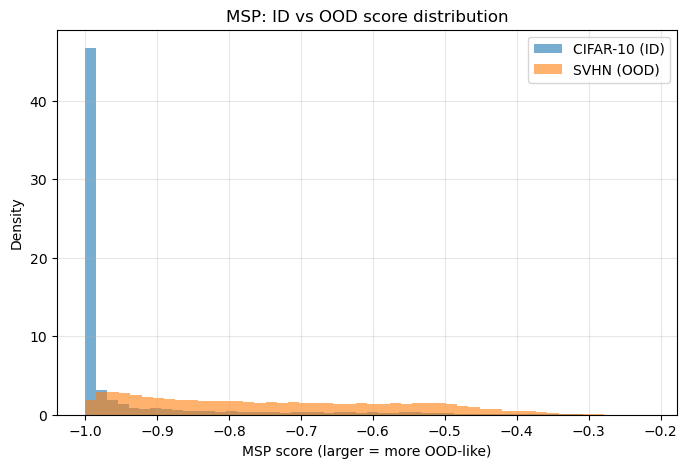

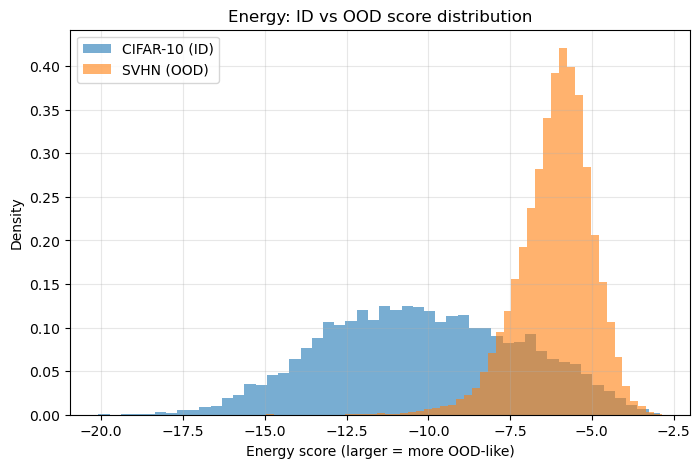

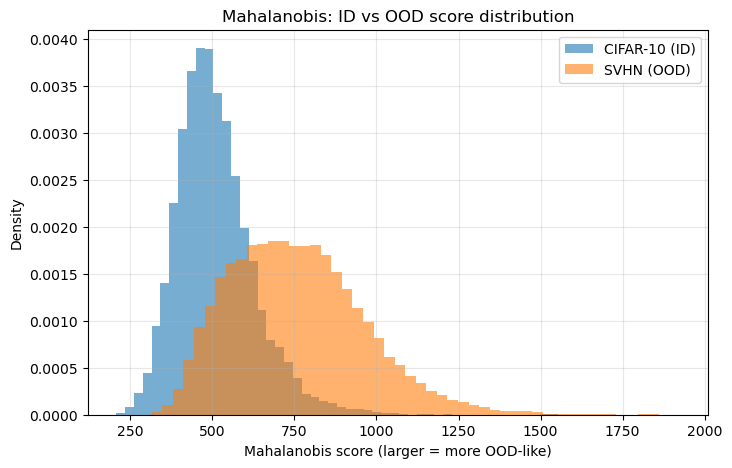

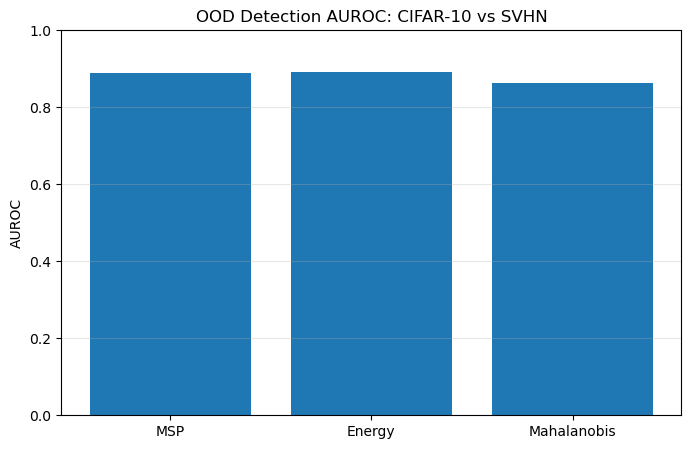

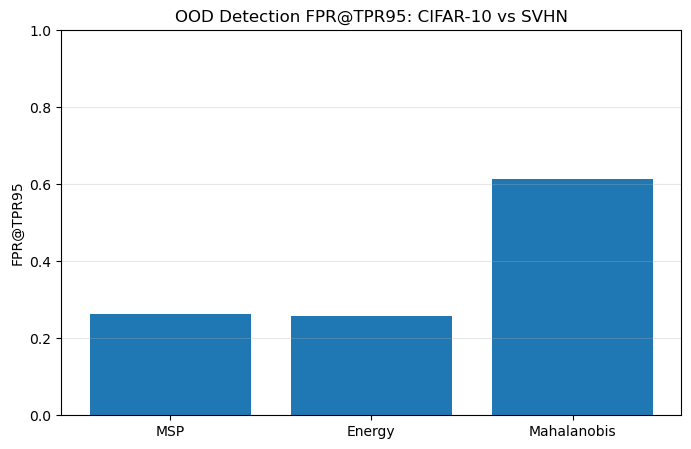


Saved Step 3 results to: /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_outputs/step3_ood_svhn_results.npz
Step 3 finished.


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import resnet18
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.covariance import EmpiricalCovariance


# Paths

PROJECT_ROOT = os.getcwd()
DATA_ROOT = os.path.join(PROJECT_ROOT, "shift_aware_conformal_data")
OUTPUT_ROOT = os.path.join(PROJECT_ROOT, "shift_aware_conformal_outputs")

MODEL_PATH = os.path.join(OUTPUT_ROOT, "resnet18_cifar10_best_debug.pt")
RESULTS_NPZ = os.path.join(OUTPUT_ROOT, "step3_ood_svhn_results.npz")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT   :", DATA_ROOT)
print("OUTPUT_ROOT :", OUTPUT_ROOT)
print("MODEL_PATH  :", MODEL_PATH)

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Missing trained model: {MODEL_PATH}")


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device      :", device)


BATCH_SIZE = 128
NUM_WORKERS = 0
TEMPERATURE = 1.0
NUM_CLASSES = 10


# Model

class ResNet18CIFAR(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.backbone = resnet18(weights=None)
        self.backbone.conv1 = nn.Conv2d(
            3, 64, kernel_size=3, stride=1, padding=1, bias=False
        )
        self.backbone.maxpool = nn.Identity()
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

    def forward_with_features(self, x):
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)

        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)
        x = self.backbone.layer3(x)
        x = self.backbone.layer4(x)

        x = self.backbone.avgpool(x)
        features = torch.flatten(x, 1)
        logits = self.backbone.fc(features)
        return logits, features


transform_eval = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    ),
])


# Datasets

# CIFAR-10 train is needed for Mahalanobis class statistics
cifar10_train = datasets.CIFAR10(
    root=DATA_ROOT,
    train=True,
    download=True,
    transform=transform_eval
)

cifar10_test = datasets.CIFAR10(
    root=DATA_ROOT,
    train=False,
    download=True,
    transform=transform_eval
)

svhn_test = datasets.SVHN(
    root=DATA_ROOT,
    split="test",
    download=True,
    transform=transform_eval
)

train_loader = DataLoader(
    cifar10_train,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

id_loader = DataLoader(
    cifar10_test,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

ood_loader = DataLoader(
    svhn_test,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print("CIFAR-10 train size:", len(cifar10_train))
print("CIFAR-10 test size :", len(cifar10_test))
print("SVHN test size     :", len(svhn_test))


model = ResNet18CIFAR(num_classes=NUM_CLASSES).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
print("Loaded model successfully.")


def get_logits_features_labels(model, loader, device, desc="Collect"):
    model.eval()
    all_logits = []
    all_features = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc=desc):
            images = images.to(device)
            logits, features = model.forward_with_features(images)

            all_logits.append(logits.cpu().numpy())
            all_features.append(features.cpu().numpy())
            all_labels.append(labels.numpy())

    return (
        np.concatenate(all_logits, axis=0),
        np.concatenate(all_features, axis=0),
        np.concatenate(all_labels, axis=0),
    )

def msp_score_from_logits(logits):
    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
    return -np.max(probs, axis=1)  # larger = more OOD-like

def energy_score_from_logits(logits, T=1.0):
    logits_t = torch.tensor(logits) / T
    energy = -T * torch.logsumexp(logits_t, dim=1)
    return energy.numpy()  # for this convention, more positive often more OOD-like after comparison

def compute_fpr_at_tpr95(id_scores, ood_scores):
    y_true = np.concatenate([
        np.zeros(len(id_scores), dtype=int),
        np.ones(len(ood_scores), dtype=int)
    ])
    y_score = np.concatenate([id_scores, ood_scores])

    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    idx = np.argmin(np.abs(tpr - 0.95))
    return fpr[idx]

def compute_auroc(id_scores, ood_scores):
    y_true = np.concatenate([
        np.zeros(len(id_scores), dtype=int),
        np.ones(len(ood_scores), dtype=int)
    ])
    y_score = np.concatenate([id_scores, ood_scores])
    return roc_auc_score(y_true, y_score)


# Collect train features for Mahalanobis

train_logits, train_features, train_labels = get_logits_features_labels(
    model, train_loader, device, desc="Collect CIFAR-10 train features"
)

print("train_features shape:", train_features.shape)
print("train_labels shape  :", train_labels.shape)


# Fit Mahalanobis statistics

class_means = []
for c in range(NUM_CLASSES):
    cls_feats = train_features[train_labels == c]
    class_means.append(cls_feats.mean(axis=0))
class_means = np.stack(class_means, axis=0)

cov = EmpiricalCovariance(assume_centered=False)
cov.fit(train_features)
precision = cov.precision_

def mahalanobis_score(features, class_means, precision):
    # larger distance = more OOD-like
    dists = []
    for c in range(class_means.shape[0]):
        diff = features - class_means[c]
        dist_c = np.sum((diff @ precision) * diff, axis=1)
        dists.append(dist_c)
    dists = np.stack(dists, axis=1)
    return np.min(dists, axis=1)

print("Mahalanobis statistics fitted.")


# Collect ID / OOD outputs

id_logits, id_features, id_labels = get_logits_features_labels(
    model, id_loader, device, desc="Collect CIFAR-10 test"
)

ood_logits, ood_features, ood_labels = get_logits_features_labels(
    model, ood_loader, device, desc="Collect SVHN test"
)

print("id_logits shape :", id_logits.shape)
print("ood_logits shape:", ood_logits.shape)


# Compute OOD scores

# MSP
id_msp = msp_score_from_logits(id_logits)
ood_msp = msp_score_from_logits(ood_logits)

# Energy
id_energy_raw = energy_score_from_logits(id_logits, T=TEMPERATURE)
ood_energy_raw = energy_score_from_logits(ood_logits, T=TEMPERATURE)

# We want larger = more OOD-like.
# Energy convention can flip, so align direction automatically.
energy_auroc_direct = compute_auroc(id_energy_raw, ood_energy_raw)
energy_auroc_flipped = compute_auroc(-id_energy_raw, -ood_energy_raw)

if energy_auroc_flipped > energy_auroc_direct:
    id_energy = -id_energy_raw
    ood_energy = -ood_energy_raw
    energy_flip_used = True
else:
    id_energy = id_energy_raw
    ood_energy = ood_energy_raw
    energy_flip_used = False

# Mahalanobis
id_maha = mahalanobis_score(id_features, class_means, precision)
ood_maha = mahalanobis_score(ood_features, class_means, precision)


# Metrics

results = {}

for name, id_scores, ood_scores in [
    ("MSP", id_msp, ood_msp),
    ("Energy", id_energy, ood_energy),
    ("Mahalanobis", id_maha, ood_maha),
]:
    auroc = compute_auroc(id_scores, ood_scores)
    fpr95 = compute_fpr_at_tpr95(id_scores, ood_scores)

    results[name] = {
        "auroc": auroc,
        "fpr95": fpr95,
        "id_mean": float(np.mean(id_scores)),
        "ood_mean": float(np.mean(ood_scores)),
    }

print("\n" + "=" * 70)
print("STEP 3 RESULTS: CIFAR-10 (ID) vs SVHN (OOD)")
print("=" * 70)

for name, vals in results.items():
    print(f"{name:12s} | AUROC = {vals['auroc']:.4f} | FPR@TPR95 = {vals['fpr95']:.4f} | "
          f"ID mean = {vals['id_mean']:.4f} | OOD mean = {vals['ood_mean']:.4f}")

print("\nEnergy score flipped direction automatically:", energy_flip_used)


for name, id_scores, ood_scores in [
    ("MSP", id_msp, ood_msp),
    ("Energy", id_energy, ood_energy),
    ("Mahalanobis", id_maha, ood_maha),
]:
    plt.figure(figsize=(8, 5))
    plt.hist(id_scores, bins=50, alpha=0.6, label="CIFAR-10 (ID)", density=True)
    plt.hist(ood_scores, bins=50, alpha=0.6, label="SVHN (OOD)", density=True)
    plt.xlabel(f"{name} score (larger = more OOD-like)")
    plt.ylabel("Density")
    plt.title(f"{name}: ID vs OOD score distribution")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


method_names = list(results.keys())
aurocs = [results[m]["auroc"] for m in method_names]
fpr95s = [results[m]["fpr95"] for m in method_names]

plt.figure(figsize=(8, 5))
plt.bar(method_names, aurocs)
plt.ylabel("AUROC")
plt.title("OOD Detection AUROC: CIFAR-10 vs SVHN")
plt.ylim(0, 1.0)
plt.grid(True, axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(method_names, fpr95s)
plt.ylabel("FPR@TPR95")
plt.title("OOD Detection FPR@TPR95: CIFAR-10 vs SVHN")
plt.ylim(0, 1.0)
plt.grid(True, axis="y", alpha=0.3)
plt.show()


np.savez_compressed(
    RESULTS_NPZ,
    id_msp=id_msp,
    ood_msp=ood_msp,
    id_energy=id_energy,
    ood_energy=ood_energy,
    id_maha=id_maha,
    ood_maha=ood_maha,
    msp_auroc=np.array(results["MSP"]["auroc"]),
    msp_fpr95=np.array(results["MSP"]["fpr95"]),
    energy_auroc=np.array(results["Energy"]["auroc"]),
    energy_fpr95=np.array(results["Energy"]["fpr95"]),
    maha_auroc=np.array(results["Mahalanobis"]["auroc"]),
    maha_fpr95=np.array(results["Mahalanobis"]["fpr95"]),
    energy_flip_used=np.array(int(energy_flip_used)),
)

print("\nSaved Step 3 results to:", RESULTS_NPZ)
print("Step 3 finished.")

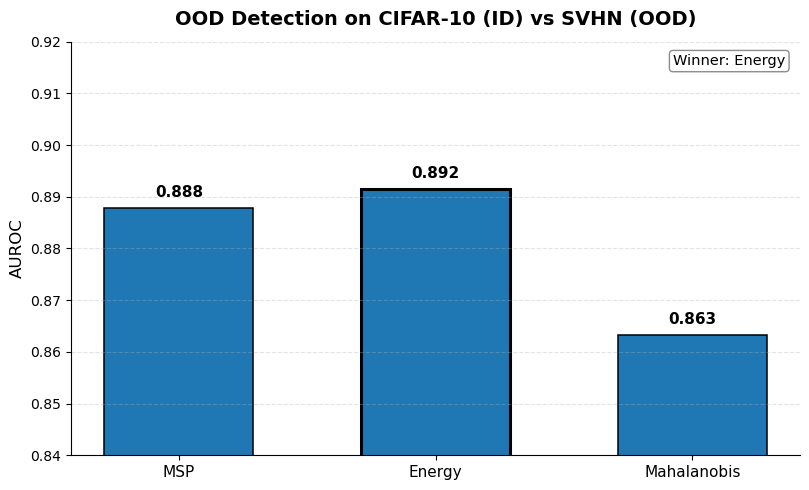

In [6]:
import matplotlib.pyplot as plt
import numpy as np

methods = ["MSP", "Energy", "Mahalanobis"]
aurocs = np.array([
    results["MSP"]["auroc"],
    results["Energy"]["auroc"],
    results["Mahalanobis"]["auroc"],
])

x = np.arange(len(methods))
best_idx = int(np.argmax(aurocs))

fig, ax = plt.subplots(figsize=(8.2, 5.0))

bars = ax.bar(
    x,
    aurocs,
    width=0.58,
    edgecolor="black",
    linewidth=1.1
)

# emphasize best bar
bars[best_idx].set_linewidth(2.2)

ax.set_title("OOD Detection on CIFAR-10 (ID) vs SVHN (OOD)", fontsize=14, weight="bold", pad=12)
ax.set_ylabel("AUROC", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=11)
ax.set_ylim(0.84, 0.92)

ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for i, (bar, val) in enumerate(zip(bars, aurocs)):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        val + 0.0015,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax.text(
    0.98, 0.97,
    f"Winner: {methods[best_idx]}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10.5,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="gray", alpha=0.9)
)

plt.tight_layout()
plt.show()

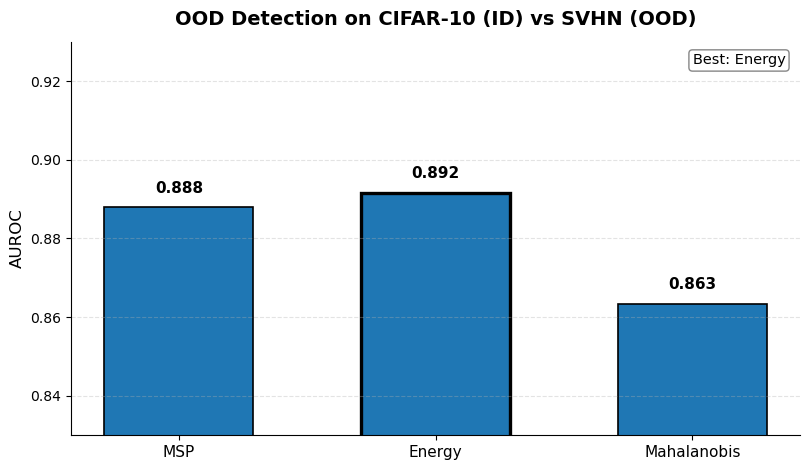

Saved figure to: /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_outputs/step3_ood_auroc_bar.png


In [7]:
import matplotlib.pyplot as plt
import numpy as np

# assumes Step 3 already created:
# results["MSP"]["auroc"]
# results["Energy"]["auroc"]
# results["Mahalanobis"]["auroc"]

methods = ["MSP", "Energy", "Mahalanobis"]
aurocs = np.array([
    results["MSP"]["auroc"],
    results["Energy"]["auroc"],
    results["Mahalanobis"]["auroc"],
])

x = np.arange(len(methods))
best_idx = int(np.argmax(aurocs))

fig, ax = plt.subplots(figsize=(8.2, 4.8))

bars = ax.bar(
    x,
    aurocs,
    width=0.58,
    edgecolor="black",
    linewidth=1.2
)

# emphasize best bar
bars[best_idx].set_linewidth(2.4)

# titles and labels
ax.set_title("OOD Detection on CIFAR-10 (ID) vs SVHN (OOD)", fontsize=14, weight="bold", pad=12)
ax.set_ylabel("AUROC", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=11)

# zoomed y-axis for cleaner visual separation
ymin = max(0.0, np.floor((aurocs.min() - 0.03) * 100) / 100)
ymax = min(1.0, np.ceil((aurocs.max() + 0.03) * 100) / 100)
ax.set_ylim(ymin, ymax)

# clean paper-style formatting
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# annotate bars
for bar, val in zip(bars, aurocs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.003,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# winner box
ax.text(
    0.98, 0.97,
    f"Best: {methods[best_idx]}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10.5,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="gray", alpha=0.95)
)

plt.tight_layout()

# save figure for paper
output_path = os.path.join(OUTPUT_ROOT, "step3_ood_auroc_bar.png")
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure to:", output_path)

In [1]:
# Step 3B: conformalized Energy gate.


PROJECT_ROOT: /Users/arifhossen/Documents/shift_aware_conformal
DATA_ROOT   : /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_data
OUTPUT_ROOT : /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_outputs
FIG_DIR     : /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_outputs/step3_conformal_gate_figures
CAL_PATH    : /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_outputs/cal_outputs_full.npz
TEST_PATH   : /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_outputs/test_outputs_full.npz
MODEL_PATH  : /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_outputs/resnet18_cifar10_best_debug.pt
CIFAR10C    : /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_data/CIFAR-10-C
Device      : cpu

Loaded saved logits:
cal_logits        : (5000, 10)
cal_labels        : (5000,)
clean_test_logits : (10000, 10)
clean_test_labels : (10000,)

Energy sc


SVHN energy summary
SVHN OOD             | mean=-6.1169 | std=1.1119 | min=-14.9743 | max=-2.8508

CLEAN vs OOD GATE SUMMARY
calibration_id  | delta=0.05 | threshold=-5.355030 | trigger_rate=0.0500
clean_test_id   | delta=0.05 | threshold=-5.355030 | trigger_rate=0.0524
svhn_ood        | delta=0.05 | threshold=-5.355030 | trigger_rate=0.2404
calibration_id  | delta=0.10 | threshold=-6.272094 | trigger_rate=0.1000
clean_test_id   | delta=0.10 | threshold=-6.272094 | trigger_rate=0.1062
svhn_ood        | delta=0.10 | threshold=-6.272094 | trigger_rate=0.6057

Corruption: gaussian_noise


severity=1 | delta=0.05 | trigger_rate=0.1458 | energy_mean=-8.0688
severity=1 | delta=0.10 | trigger_rate=0.2845 | energy_mean=-8.0688


severity=2 | delta=0.05 | trigger_rate=0.2091 | energy_mean=-7.2194
severity=2 | delta=0.10 | trigger_rate=0.4068 | energy_mean=-7.2194


severity=3 | delta=0.05 | trigger_rate=0.2281 | energy_mean=-6.9699
severity=3 | delta=0.10 | trigger_rate=0.4474 | energy_mean=-6.9699


...

severity=1 | delta=0.05 | trigger_rate=0.1077 | energy_mean=-8.7901
severity=1 | delta=0.10 | trigger_rate=0.2048 | energy_mean=-8.7901


severity=2 | delta=0.05 | trigger_rate=0.1467 | energy_mean=-8.1739
severity=2 | delta=0.10 | trigger_rate=0.2674 | energy_mean=-8.1739


severity=3 | delta=0.05 | trigger_rate=0.1645 | energy_mean=-7.9840
severity=3 | delta=0.10 | trigger_rate=0.2918 | energy_mean=-7.9840


severity=4 | delta=0.05 | trigger_rate=0.1846 | energy_mean=-7.7912
severity=4 | delta=0.10 | trigger_rate=0.3198 | energy_mean=-7.7912


severity=5 | delta=0.05 | trigger_rate=0.2093 | energy_mean=-7.5076
severity=5 | delta=0.10 | trigger_rate=0.3543 | energy_mean=-7.5076

Saved CSV files:
 - /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_outputs/step3b_energy_gate_summary.csv
 - /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_outputs/step3b_energy_gate_cifar10c.csv
Saved NPZ: /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_outputs/step3b_energy_gate_results.npz


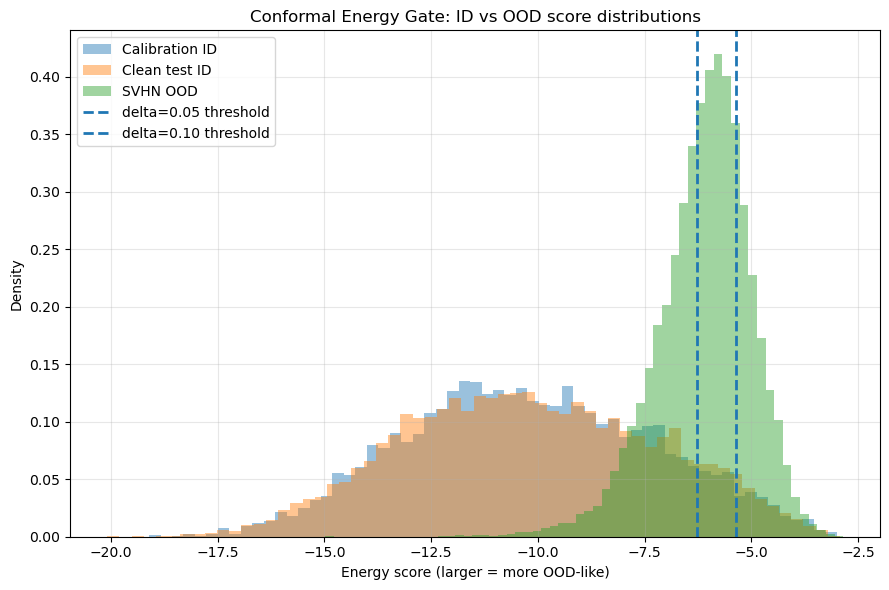

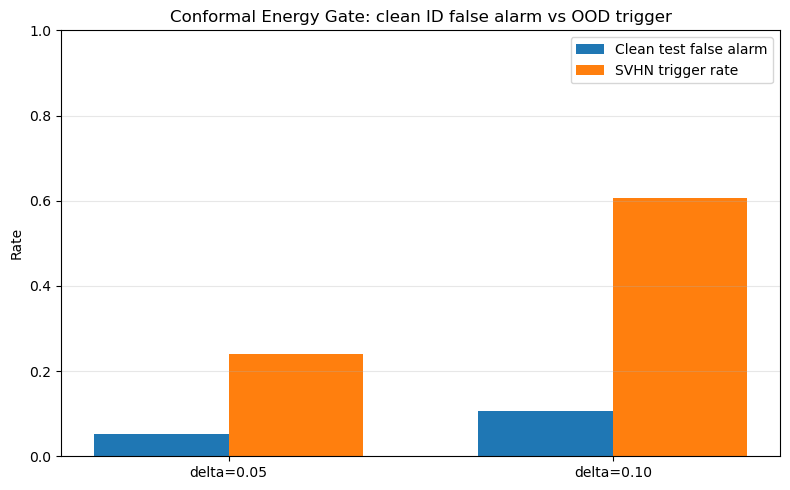

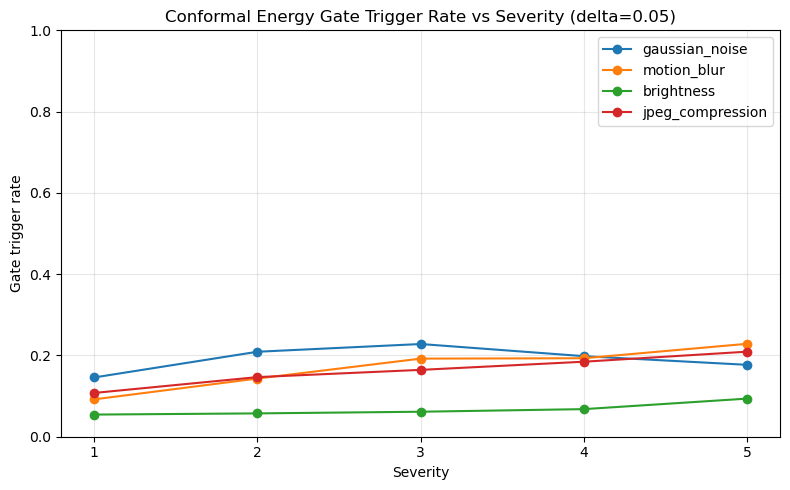

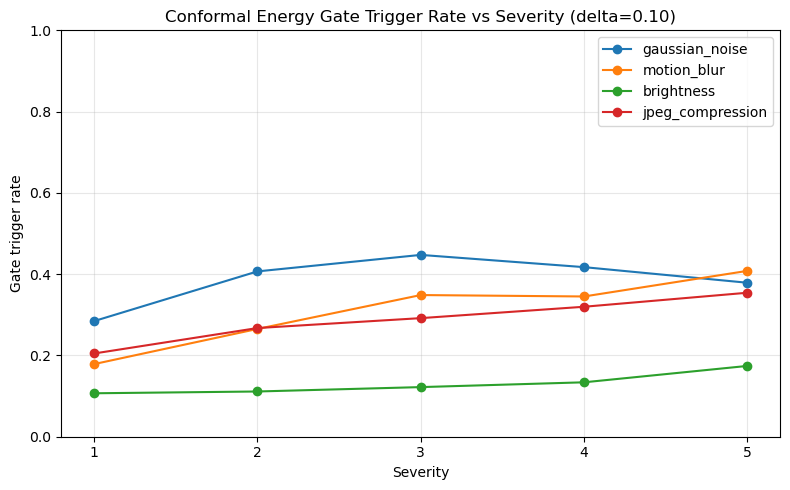

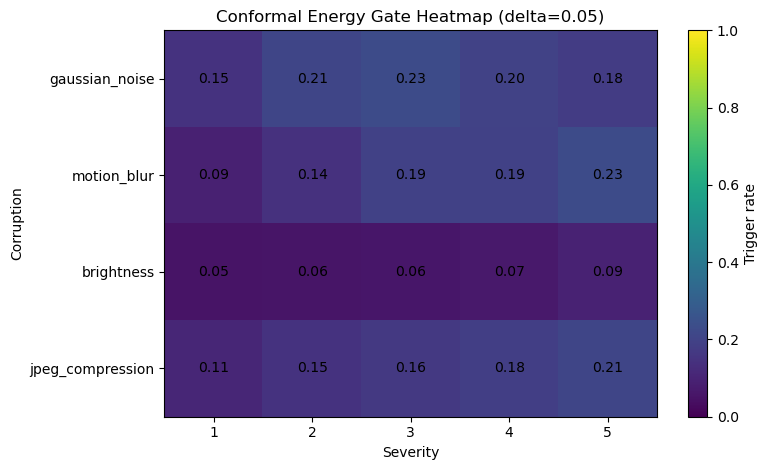

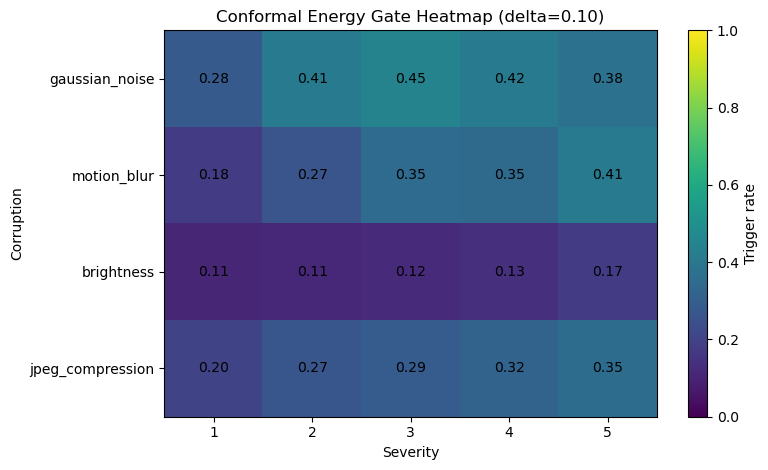


STEP 3B SUMMARY

Delta = 0.05
Clean test false alarm rate : 0.0524
SVHN trigger rate           : 0.2404
gaussian_noise       | severity-5 trigger = 0.1769 | max trigger = 0.2281
motion_blur          | severity-5 trigger = 0.2287 | max trigger = 0.2287
brightness           | severity-5 trigger = 0.0938 | max trigger = 0.0938
jpeg_compression     | severity-5 trigger = 0.2093 | max trigger = 0.2093

Delta = 0.10
Clean test false alarm rate : 0.1062
SVHN trigger rate           : 0.6057
gaussian_noise       | severity-5 trigger = 0.3789 | max trigger = 0.4474
motion_blur          | severity-5 trigger = 0.4081 | max trigger = 0.4081
brightness           | severity-5 trigger = 0.1742 | max trigger = 0.1742
jpeg_compression     | severity-5 trigger = 0.3543 | max trigger = 0.3543

Saved figures in: /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_outputs/step3_conformal_gate_figures
Step 3B finished.


In [2]:
import os
import csv
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from torchvision.models import resnet18


# Paths

PROJECT_ROOT = os.getcwd()
DATA_ROOT = os.path.join(PROJECT_ROOT, "shift_aware_conformal_data")
OUTPUT_ROOT = os.path.join(PROJECT_ROOT, "shift_aware_conformal_outputs")
FIG_DIR = os.path.join(OUTPUT_ROOT, "step3_conformal_gate_figures")

os.makedirs(FIG_DIR, exist_ok=True)

CAL_PATH = os.path.join(OUTPUT_ROOT, "cal_outputs_full.npz")
TEST_PATH = os.path.join(OUTPUT_ROOT, "test_outputs_full.npz")
MODEL_PATH = os.path.join(OUTPUT_ROOT, "resnet18_cifar10_best_debug.pt")
CIFAR10C_ROOT = os.path.join(DATA_ROOT, "CIFAR-10-C")

SUMMARY_CSV = os.path.join(OUTPUT_ROOT, "step3b_energy_gate_summary.csv")
SHIFT_CSV = os.path.join(OUTPUT_ROOT, "step3b_energy_gate_cifar10c.csv")
RESULTS_NPZ = os.path.join(OUTPUT_ROOT, "step3b_energy_gate_results.npz")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT   :", DATA_ROOT)
print("OUTPUT_ROOT :", OUTPUT_ROOT)
print("FIG_DIR     :", FIG_DIR)
print("CAL_PATH    :", CAL_PATH)
print("TEST_PATH   :", TEST_PATH)
print("MODEL_PATH  :", MODEL_PATH)
print("CIFAR10C    :", CIFAR10C_ROOT)


for path in [CAL_PATH, TEST_PATH, MODEL_PATH]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing required file: {path}")

if not os.path.exists(CIFAR10C_ROOT):
    raise FileNotFoundError(f"Missing CIFAR-10-C folder: {CIFAR10C_ROOT}")


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device      :", device)


BATCH_SIZE = 128
NUM_WORKERS = 0
NUM_CLASSES = 10
TEMPERATURE = 1.0

# Gate operating points
DELTAS = [0.05, 0.10]

CORRUPTIONS = [
    "gaussian_noise",
    "motion_blur",
    "brightness",
    "jpeg_compression",
]

SEVERITIES = [1, 2, 3, 4, 5]


class ResNet18CIFAR(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.backbone = resnet18(weights=None)
        self.backbone.conv1 = nn.Conv2d(
            3, 64, kernel_size=3, stride=1, padding=1, bias=False
        )
        self.backbone.maxpool = nn.Identity()
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)


# CIFAR-10-C dataset

class CIFAR10CDataset(Dataset):
    def __init__(self, cifar10c_root, corruption_name, severity, transform=None):
        self.transform = transform

        corruption_path = os.path.join(cifar10c_root, f"{corruption_name}.npy")
        labels_path = os.path.join(cifar10c_root, "labels.npy")

        if not os.path.exists(corruption_path):
            raise FileNotFoundError(f"Missing corruption file: {corruption_path}")
        if not os.path.exists(labels_path):
            raise FileNotFoundError(f"Missing labels file: {labels_path}")

        all_images = np.load(corruption_path)
        all_labels = np.load(labels_path)

        start = (severity - 1) * 10000
        end = severity * 10000

        self.images = all_images[start:end]
        self.labels = all_labels[start:end]

        assert len(self.images) == 10000
        assert len(self.labels) == 10000

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx]
        label = int(self.labels[idx])

        if self.transform is not None:
            img = self.transform(img)

        return img, label


transform_eval = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616),
    ),
])

transform_cifar10c = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616),
    ),
])


def energy_score_from_logits(logits, T=1.0):
    """
    Energy score:
        E(x) = -T * logsumexp(logits / T)

    In your setup, larger (less negative) values are more OOD-like.
    """
    logits_t = torch.tensor(logits, dtype=torch.float32) / T
    energy = -T * torch.logsumexp(logits_t, dim=1)
    return energy.numpy()

def collect_logits(model, loader, device, desc="Collect logits"):
    model.eval()
    all_logits = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc=desc, leave=False):
            images = images.to(device)
            logits = model(images)
            all_logits.append(logits.cpu().numpy())
            all_labels.append(labels.numpy())

    return np.concatenate(all_logits, axis=0), np.concatenate(all_labels, axis=0)

def conformal_upper_quantile(scores, delta):
    """
    One-sided conformal threshold for target ID false alarm rate delta.
    """
    n = len(scores)
    k = int(np.ceil((n + 1) * (1 - delta))) - 1
    k = min(max(k, 0), n - 1)
    return np.sort(scores)[k]

def trigger_rate(scores, threshold):
    return float(np.mean(scores >= threshold))

def summarize_scores(name, scores):
    print(
        f"{name:20s} | mean={np.mean(scores):.4f} | std={np.std(scores):.4f} | "
        f"min={np.min(scores):.4f} | max={np.max(scores):.4f}"
    )


# Load saved calibration / clean test logits

cal_data = np.load(CAL_PATH)
test_data = np.load(TEST_PATH)

if "logits" not in cal_data.files:
    raise KeyError(
        f"'logits' not found in {CAL_PATH}. "
        "Please re-run Step 1 and save calibration logits."
    )

if "logits" not in test_data.files:
    raise KeyError(
        f"'logits' not found in {TEST_PATH}. "
        "Please re-run Step 1 and save clean test logits."
    )

cal_logits = cal_data["logits"]
cal_labels = cal_data["labels"]

clean_test_logits = test_data["logits"]
clean_test_labels = test_data["labels"]

print("\nLoaded saved logits:")
print("cal_logits        :", cal_logits.shape)
print("cal_labels        :", cal_labels.shape)
print("clean_test_logits :", clean_test_logits.shape)
print("clean_test_labels :", clean_test_labels.shape)


# Compute calibration + clean-test energy

cal_energy = energy_score_from_logits(cal_logits, T=TEMPERATURE)
clean_test_energy = energy_score_from_logits(clean_test_logits, T=TEMPERATURE)

print("\nEnergy score summaries")
summarize_scores("Calibration ID", cal_energy)
summarize_scores("Clean test ID", clean_test_energy)


# Build conformal gate thresholds

threshold_rows = []

for delta in DELTAS:
    t_hat = conformal_upper_quantile(cal_energy, delta)

    row = {
        "delta": delta,
        "threshold": float(t_hat),
        "calibration_trigger_rate": trigger_rate(cal_energy, t_hat),
        "clean_test_false_alarm_rate": trigger_rate(clean_test_energy, t_hat),
    }
    threshold_rows.append(row)

print("\n" + "=" * 80)
print("CONFORMAL ENERGY GATE THRESHOLDS")
print("=" * 80)
for row in threshold_rows:
    print(
        f"delta={row['delta']:.2f} | "
        f"threshold={row['threshold']:.6f} | "
        f"cal_trigger={row['calibration_trigger_rate']:.4f} | "
        f"clean_test_FA={row['clean_test_false_alarm_rate']:.4f}"
    )


# Load model for SVHN + CIFAR-10-C inference

model = ResNet18CIFAR(num_classes=NUM_CLASSES).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
print("\nLoaded model successfully.")


# SVHN OOD dataset

svhn_test = datasets.SVHN(
    root=DATA_ROOT,
    split="test",
    download=True,
    transform=transform_eval,
)

svhn_loader = DataLoader(
    svhn_test,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

svhn_logits, svhn_labels = collect_logits(model, svhn_loader, device, desc="SVHN logits")
svhn_energy = energy_score_from_logits(svhn_logits, T=TEMPERATURE)

print("\nSVHN energy summary")
summarize_scores("SVHN OOD", svhn_energy)


# Evaluate clean + SVHN summary

summary_rows = []

for row in threshold_rows:
    delta = row["delta"]
    t_hat = row["threshold"]

    summary_rows.append({
        "dataset": "calibration_id",
        "delta": delta,
        "threshold": t_hat,
        "trigger_rate": trigger_rate(cal_energy, t_hat),
    })
    summary_rows.append({
        "dataset": "clean_test_id",
        "delta": delta,
        "threshold": t_hat,
        "trigger_rate": trigger_rate(clean_test_energy, t_hat),
    })
    summary_rows.append({
        "dataset": "svhn_ood",
        "delta": delta,
        "threshold": t_hat,
        "trigger_rate": trigger_rate(svhn_energy, t_hat),
    })

print("\n" + "=" * 80)
print("CLEAN vs OOD GATE SUMMARY")
print("=" * 80)
for row in summary_rows:
    print(
        f"{row['dataset']:15s} | delta={row['delta']:.2f} | "
        f"threshold={row['threshold']:.6f} | trigger_rate={row['trigger_rate']:.4f}"
    )


# CIFAR-10-C gate evaluation

shift_rows = []

for corruption in CORRUPTIONS:
    print("\n" + "=" * 80)
    print("Corruption:", corruption)

    for severity in SEVERITIES:
        dataset = CIFAR10CDataset(
            cifar10c_root=CIFAR10C_ROOT,
            corruption_name=corruption,
            severity=severity,
            transform=transform_cifar10c,
        )

        loader = DataLoader(
            dataset,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=NUM_WORKERS,
        )

        logits, labels = collect_logits(
            model,
            loader,
            device,
            desc=f"{corruption} sev{severity}"
        )

        energy_scores = energy_score_from_logits(logits, T=TEMPERATURE)

        for row in threshold_rows:
            delta = row["delta"]
            t_hat = row["threshold"]

            gate_rate = trigger_rate(energy_scores, t_hat)

            out_row = {
                "corruption": corruption,
                "severity": severity,
                "delta": delta,
                "threshold": t_hat,
                "trigger_rate": gate_rate,
                "energy_mean": float(np.mean(energy_scores)),
                "energy_std": float(np.std(energy_scores)),
            }
            shift_rows.append(out_row)

            print(
                f"severity={severity} | delta={delta:.2f} | "
                f"trigger_rate={gate_rate:.4f} | energy_mean={np.mean(energy_scores):.4f}"
            )


with open(SUMMARY_CSV, "w", newline="") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=["dataset", "delta", "threshold", "trigger_rate"]
    )
    writer.writeheader()
    writer.writerows(summary_rows)

with open(SHIFT_CSV, "w", newline="") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=[
            "corruption", "severity", "delta",
            "threshold", "trigger_rate", "energy_mean", "energy_std"
        ]
    )
    writer.writeheader()
    writer.writerows(shift_rows)

print("\nSaved CSV files:")
print(" -", SUMMARY_CSV)
print(" -", SHIFT_CSV)


np.savez_compressed(
    RESULTS_NPZ,
    cal_energy=cal_energy,
    clean_test_energy=clean_test_energy,
    svhn_energy=svhn_energy,
    deltas=np.array(DELTAS),
    thresholds=np.array([r["threshold"] for r in threshold_rows]),
    summary_rows=np.array(summary_rows, dtype=object),
    shift_rows=np.array(shift_rows, dtype=object),
)

print("Saved NPZ:", RESULTS_NPZ)


plt.figure(figsize=(9, 6))
plt.hist(cal_energy, bins=60, alpha=0.45, density=True, label="Calibration ID")
plt.hist(clean_test_energy, bins=60, alpha=0.45, density=True, label="Clean test ID")
plt.hist(svhn_energy, bins=60, alpha=0.45, density=True, label="SVHN OOD")

for row in threshold_rows:
    plt.axvline(
        row["threshold"],
        linestyle="--",
        linewidth=2,
        label=f"delta={row['delta']:.2f} threshold"
    )

plt.xlabel("Energy score (larger = more OOD-like)")
plt.ylabel("Density")
plt.title("Conformal Energy Gate: ID vs OOD score distributions")
plt.legend()
plt.grid(True, alpha=0.3)
hist_path = os.path.join(FIG_DIR, "energy_histograms_with_thresholds.png")
plt.tight_layout()
plt.savefig(hist_path, dpi=300, bbox_inches="tight")
plt.show()


x_labels = [f"delta={d:.2f}" for d in DELTAS]
clean_rates = [
    next(r["trigger_rate"] for r in summary_rows if r["dataset"] == "clean_test_id" and abs(r["delta"] - d) < 1e-12)
    for d in DELTAS
]
svhn_rates = [
    next(r["trigger_rate"] for r in summary_rows if r["dataset"] == "svhn_ood" and abs(r["delta"] - d) < 1e-12)
    for d in DELTAS
]

x = np.arange(len(DELTAS))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width / 2, clean_rates, width, label="Clean test false alarm")
plt.bar(x + width / 2, svhn_rates, width, label="SVHN trigger rate")
plt.xticks(x, x_labels)
plt.ylabel("Rate")
plt.title("Conformal Energy Gate: clean ID false alarm vs OOD trigger")
plt.ylim(0, 1.0)
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
bar_path = os.path.join(FIG_DIR, "clean_vs_svhn_gate_rates.png")
plt.tight_layout()
plt.savefig(bar_path, dpi=300, bbox_inches="tight")
plt.show()


for delta in DELTAS:
    plt.figure(figsize=(8, 5))

    for corruption in CORRUPTIONS:
        xs = []
        ys = []
        for severity in SEVERITIES:
            row = next(
                r for r in shift_rows
                if r["corruption"] == corruption
                and r["severity"] == severity
                and abs(r["delta"] - delta) < 1e-12
            )
            xs.append(severity)
            ys.append(row["trigger_rate"])

        plt.plot(xs, ys, marker="o", label=corruption)

    plt.xlabel("Severity")
    plt.ylabel("Gate trigger rate")
    plt.title(f"Conformal Energy Gate Trigger Rate vs Severity (delta={delta:.2f})")
    plt.xticks(SEVERITIES)
    plt.ylim(0, 1.0)
    plt.grid(True, alpha=0.3)
    plt.legend()
    line_path = os.path.join(FIG_DIR, f"trigger_vs_severity_delta_{str(delta).replace('.', 'p')}.png")
    plt.tight_layout()
    plt.savefig(line_path, dpi=300, bbox_inches="tight")
    plt.show()


for delta in DELTAS:
    matrix = np.zeros((len(CORRUPTIONS), len(SEVERITIES)), dtype=np.float32)

    for i, corruption in enumerate(CORRUPTIONS):
        for j, severity in enumerate(SEVERITIES):
            row = next(
                r for r in shift_rows
                if r["corruption"] == corruption
                and r["severity"] == severity
                and abs(r["delta"] - delta) < 1e-12
            )
            matrix[i, j] = row["trigger_rate"]

    plt.figure(figsize=(8, 4.8))
    im = plt.imshow(matrix, aspect="auto", vmin=0.0, vmax=1.0)
    plt.colorbar(im, label="Trigger rate")
    plt.xticks(np.arange(len(SEVERITIES)), SEVERITIES)
    plt.yticks(np.arange(len(CORRUPTIONS)), CORRUPTIONS)
    plt.xlabel("Severity")
    plt.ylabel("Corruption")
    plt.title(f"Conformal Energy Gate Heatmap (delta={delta:.2f})")

    for i in range(len(CORRUPTIONS)):
        for j in range(len(SEVERITIES)):
            plt.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center")

    heatmap_path = os.path.join(FIG_DIR, f"heatmap_delta_{str(delta).replace('.', 'p')}.png")
    plt.tight_layout()
    plt.savefig(heatmap_path, dpi=300, bbox_inches="tight")
    plt.show()


print("\n" + "=" * 80)
print("STEP 3B SUMMARY")
print("=" * 80)

for delta in DELTAS:
    clean_rate = next(
        r["trigger_rate"] for r in summary_rows
        if r["dataset"] == "clean_test_id" and abs(r["delta"] - delta) < 1e-12
    )
    svhn_rate = next(
        r["trigger_rate"] for r in summary_rows
        if r["dataset"] == "svhn_ood" and abs(r["delta"] - delta) < 1e-12
    )

    print(f"\nDelta = {delta:.2f}")
    print(f"Clean test false alarm rate : {clean_rate:.4f}")
    print(f"SVHN trigger rate           : {svhn_rate:.4f}")

    for corruption in CORRUPTIONS:
        rows = [
            r for r in shift_rows
            if r["corruption"] == corruption and abs(r["delta"] - delta) < 1e-12
        ]
        sev5 = next(r["trigger_rate"] for r in rows if r["severity"] == 5)
        worst = max(r["trigger_rate"] for r in rows)
        print(f"{corruption:20s} | severity-5 trigger = {sev5:.4f} | max trigger = {worst:.4f}")

print("\nSaved figures in:", FIG_DIR)
print("Step 3B finished.")

PROJECT_ROOT: /Users/arifhossen/Documents/shift_aware_conformal
DATA_ROOT   : /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_data
OUTPUT_ROOT : /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_outputs
FIG_DIR     : /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_outputs/step3b_energy_gate_figures
CAL_PATH    : /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_outputs/cal_outputs_full.npz
TEST_PATH   : /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_outputs/test_outputs_full.npz
MODEL_PATH  : /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_outputs/resnet18_cifar10_best_debug.pt
CIFAR10C    : /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_data/CIFAR-10-C
Device      : cpu

Loaded saved logits:
cal_logits        : (5000, 10)
cal_labels        : (5000,)
clean_test_logits : (10000, 10)
clean_test_labels : (10000,)

Energy scor


SVHN energy summary
SVHN OOD             | mean=-6.1169 | std=1.1119 | min=-14.9743 | max=-2.8508

CLEAN vs OOD GATE SUMMARY
calibration_id  | delta=0.05 | threshold=-5.355030 | trigger_rate=0.0500
clean_test_id   | delta=0.05 | threshold=-5.355030 | trigger_rate=0.0524
svhn_ood        | delta=0.05 | threshold=-5.355030 | trigger_rate=0.2404
calibration_id  | delta=0.10 | threshold=-6.272094 | trigger_rate=0.1000
clean_test_id   | delta=0.10 | threshold=-6.272094 | trigger_rate=0.1062
svhn_ood        | delta=0.10 | threshold=-6.272094 | trigger_rate=0.6057

Corruption: gaussian_noise


severity=1 | delta=0.05 | trigger_rate=0.1458 | energy_mean=-8.0688
severity=1 | delta=0.10 | trigger_rate=0.2845 | energy_mean=-8.0688


severity=2 | delta=0.05 | trigger_rate=0.2091 | energy_mean=-7.2194
severity=2 | delta=0.10 | trigger_rate=0.4068 | energy_mean=-7.2194


severity=3 | delta=0.05 | trigger_rate=0.2281 | energy_mean=-6.9699
severity=3 | delta=0.10 | trigger_rate=0.4474 | energy_mean=-6.9699


...

severity=1 | delta=0.05 | trigger_rate=0.1077 | energy_mean=-8.7901
severity=1 | delta=0.10 | trigger_rate=0.2048 | energy_mean=-8.7901


severity=2 | delta=0.05 | trigger_rate=0.1467 | energy_mean=-8.1739
severity=2 | delta=0.10 | trigger_rate=0.2674 | energy_mean=-8.1739


severity=3 | delta=0.05 | trigger_rate=0.1645 | energy_mean=-7.9840
severity=3 | delta=0.10 | trigger_rate=0.2918 | energy_mean=-7.9840


severity=4 | delta=0.05 | trigger_rate=0.1846 | energy_mean=-7.7912
severity=4 | delta=0.10 | trigger_rate=0.3198 | energy_mean=-7.7912


severity=5 | delta=0.05 | trigger_rate=0.2093 | energy_mean=-7.5076
severity=5 | delta=0.10 | trigger_rate=0.3543 | energy_mean=-7.5076

Saved CSV files:
 - /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_outputs/step3b_energy_gate_summary.csv
 - /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_outputs/step3b_energy_gate_cifar10c.csv
Saved NPZ: /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_outputs/step3b_energy_gate_results.npz


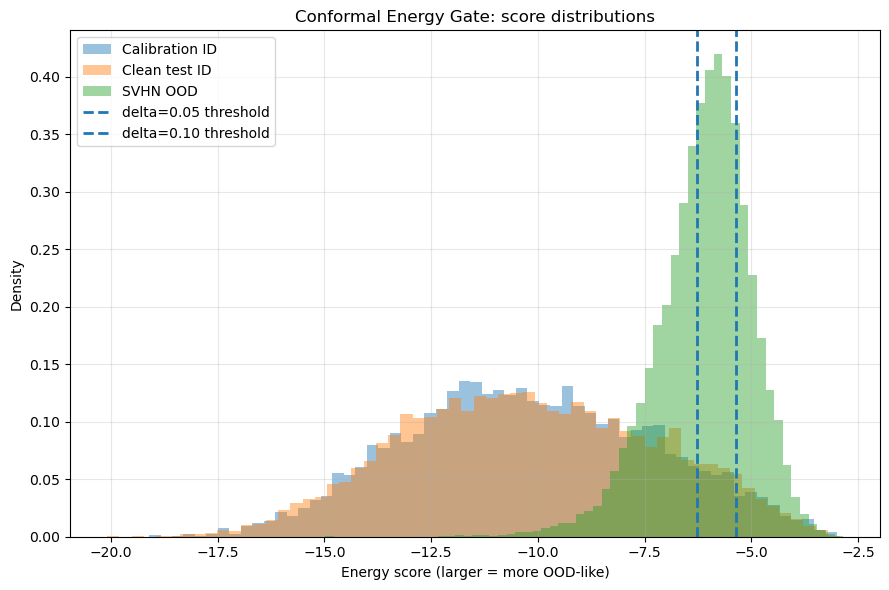

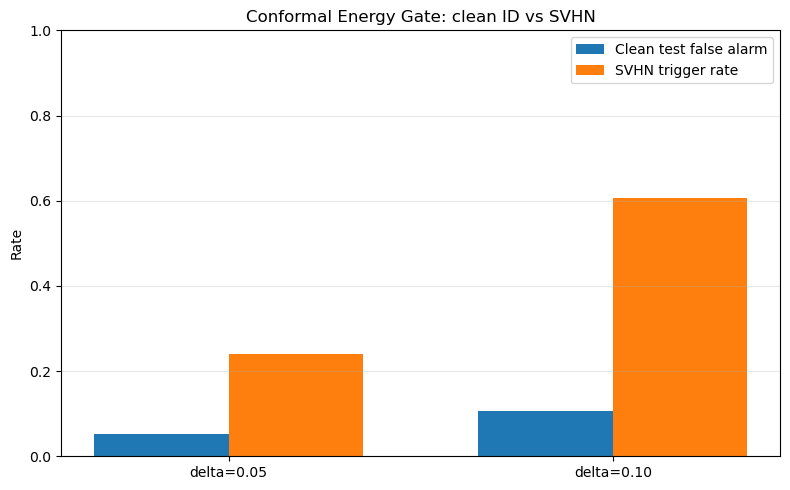

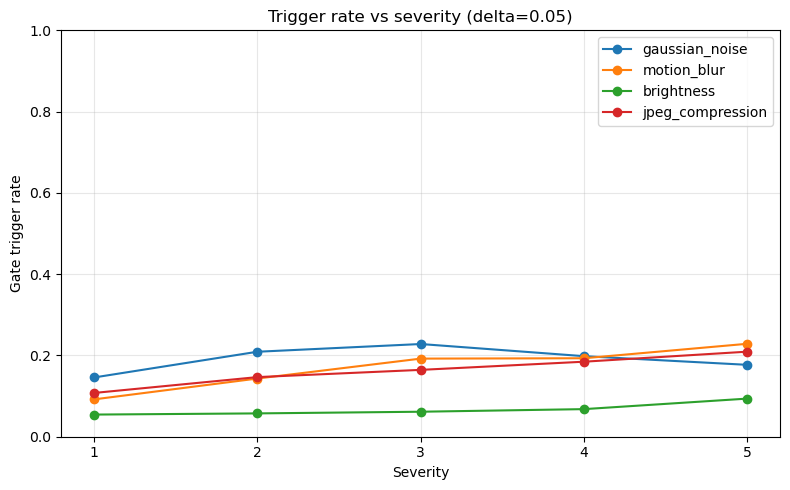

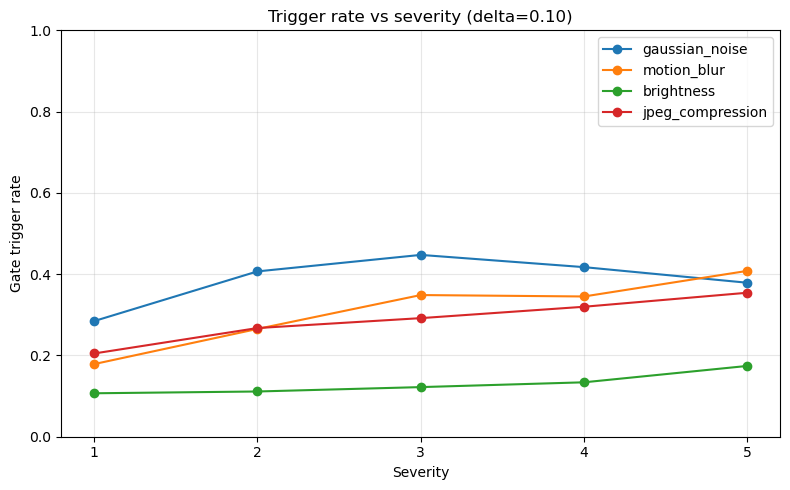

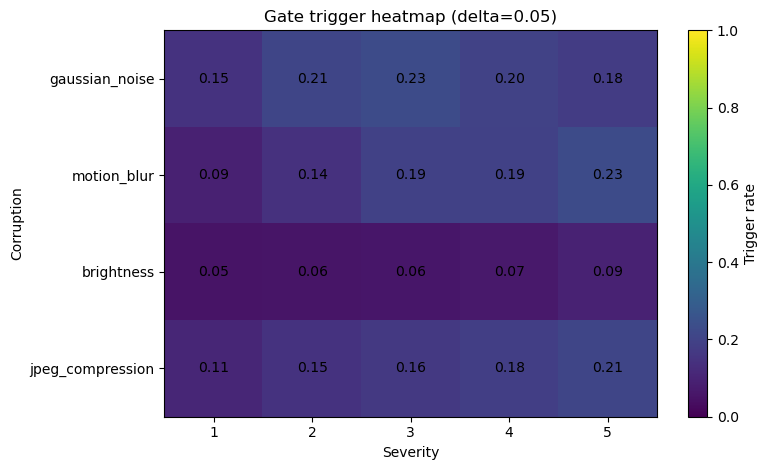

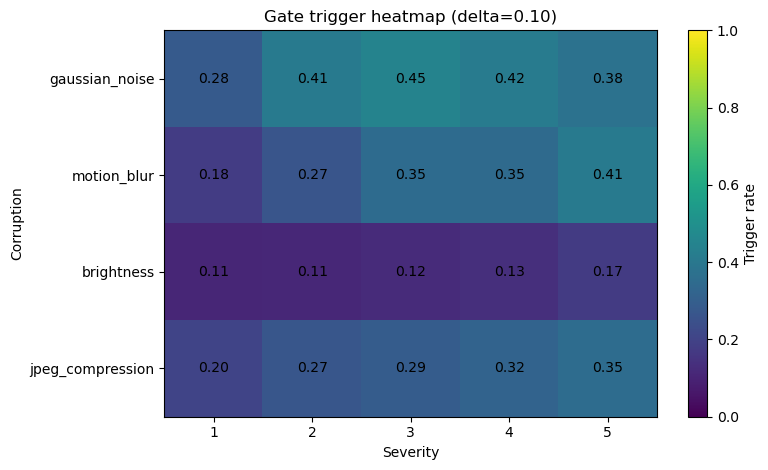


STEP 3B SUMMARY

Delta = 0.05
Clean test false alarm rate : 0.0524
SVHN trigger rate           : 0.2404
gaussian_noise       | severity-5 trigger = 0.1769 | max trigger = 0.2281
motion_blur          | severity-5 trigger = 0.2287 | max trigger = 0.2287
brightness           | severity-5 trigger = 0.0938 | max trigger = 0.0938
jpeg_compression     | severity-5 trigger = 0.2093 | max trigger = 0.2093

Delta = 0.10
Clean test false alarm rate : 0.1062
SVHN trigger rate           : 0.6057
gaussian_noise       | severity-5 trigger = 0.3789 | max trigger = 0.4474
motion_blur          | severity-5 trigger = 0.4081 | max trigger = 0.4081
brightness           | severity-5 trigger = 0.1742 | max trigger = 0.1742
jpeg_compression     | severity-5 trigger = 0.3543 | max trigger = 0.3543

Saved figures in: /Users/arifhossen/Documents/shift_aware_conformal/shift_aware_conformal_outputs/step3b_energy_gate_figures
Step 3B finished.


In [3]:
# Step 3B: conformalized Energy gate. version 2

import os
import csv
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from torchvision.models import resnet18

# ============================================================
# Paths
# ============================================================
PROJECT_ROOT = os.getcwd()
DATA_ROOT = os.path.join(PROJECT_ROOT, "shift_aware_conformal_data")
OUTPUT_ROOT = os.path.join(PROJECT_ROOT, "shift_aware_conformal_outputs")
FIG_DIR = os.path.join(OUTPUT_ROOT, "step3b_energy_gate_figures")

os.makedirs(FIG_DIR, exist_ok=True)

CAL_PATH = os.path.join(OUTPUT_ROOT, "cal_outputs_full.npz")
TEST_PATH = os.path.join(OUTPUT_ROOT, "test_outputs_full.npz")
MODEL_PATH = os.path.join(OUTPUT_ROOT, "resnet18_cifar10_best_debug.pt")
CIFAR10C_ROOT = os.path.join(DATA_ROOT, "CIFAR-10-C")

SUMMARY_CSV = os.path.join(OUTPUT_ROOT, "step3b_energy_gate_summary.csv")
SHIFT_CSV = os.path.join(OUTPUT_ROOT, "step3b_energy_gate_cifar10c.csv")
RESULTS_NPZ = os.path.join(OUTPUT_ROOT, "step3b_energy_gate_results.npz")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT   :", DATA_ROOT)
print("OUTPUT_ROOT :", OUTPUT_ROOT)
print("FIG_DIR     :", FIG_DIR)
print("CAL_PATH    :", CAL_PATH)
print("TEST_PATH   :", TEST_PATH)
print("MODEL_PATH  :", MODEL_PATH)
print("CIFAR10C    :", CIFAR10C_ROOT)

# ============================================================
# Checks
# ============================================================
required_files = [CAL_PATH, TEST_PATH, MODEL_PATH]
for path in required_files:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing required file: {path}")

if not os.path.exists(CIFAR10C_ROOT):
    raise FileNotFoundError(f"Missing CIFAR-10-C folder: {CIFAR10C_ROOT}")

# ============================================================
# Device
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device      :", device)

# ============================================================
# Settings
# ============================================================
BATCH_SIZE = 128
NUM_WORKERS = 0
NUM_CLASSES = 10
TEMPERATURE = 1.0

# Gate operating points
DELTAS = [0.05, 0.10]

CORRUPTIONS = [
    "gaussian_noise",
    "motion_blur",
    "brightness",
    "jpeg_compression",
]

SEVERITIES = [1, 2, 3, 4, 5]

# ============================================================
# Model
# ============================================================
class ResNet18CIFAR(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.backbone = resnet18(weights=None)
        self.backbone.conv1 = nn.Conv2d(
            3, 64, kernel_size=3, stride=1, padding=1, bias=False
        )
        self.backbone.maxpool = nn.Identity()
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

# ============================================================
# CIFAR-10-C dataset
# ============================================================
class CIFAR10CDataset(Dataset):
    def __init__(self, cifar10c_root, corruption_name, severity, transform=None):
        self.transform = transform

        corruption_path = os.path.join(cifar10c_root, f"{corruption_name}.npy")
        labels_path = os.path.join(cifar10c_root, "labels.npy")

        if not os.path.exists(corruption_path):
            raise FileNotFoundError(f"Missing corruption file: {corruption_path}")
        if not os.path.exists(labels_path):
            raise FileNotFoundError(f"Missing labels file: {labels_path}")

        all_images = np.load(corruption_path)
        all_labels = np.load(labels_path)

        start = (severity - 1) * 10000
        end = severity * 10000

        self.images = all_images[start:end]
        self.labels = all_labels[start:end]

        assert len(self.images) == 10000, f"Expected 10000 images, got {len(self.images)}"
        assert len(self.labels) == 10000, f"Expected 10000 labels, got {len(self.labels)}"

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx]
        label = int(self.labels[idx])

        if self.transform is not None:
            img = self.transform(img)

        return img, label

# ============================================================
# Transforms
# ============================================================
transform_eval = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616),
    ),
])

transform_cifar10c = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616),
    ),
])

# ============================================================
# Helper functions
# ============================================================
def energy_score_from_logits(logits, T=1.0):
    """
    Energy score:
        E(x) = -T * logsumexp(logits / T)

    In your current setup, larger (less negative) values are more OOD-like.
    """
    logits_t = torch.tensor(logits, dtype=torch.float32) / T
    energy = -T * torch.logsumexp(logits_t, dim=1)
    return energy.numpy()

def collect_logits(model, loader, device, desc="Collect logits"):
    model.eval()
    all_logits = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc=desc, leave=False):
            images = images.to(device)
            logits = model(images)
            all_logits.append(logits.cpu().numpy())
            all_labels.append(labels.numpy())

    logits = np.concatenate(all_logits, axis=0)
    labels = np.concatenate(all_labels, axis=0)
    return logits, labels

def conformal_upper_quantile(scores, delta):
    """
    Finite-sample one-sided conformal threshold
    controlling ID false alarm near delta.
    """
    n = len(scores)
    k = int(np.ceil((n + 1) * (1 - delta))) - 1
    k = min(max(k, 0), n - 1)
    return np.sort(scores)[k]

def trigger_rate(scores, threshold):
    return float(np.mean(scores >= threshold))

def summarize_scores(name, scores):
    print(
        f"{name:20s} | mean={np.mean(scores):.4f} | std={np.std(scores):.4f} | "
        f"min={np.min(scores):.4f} | max={np.max(scores):.4f}"
    )

# ============================================================
# Load saved calibration / clean test logits
# ============================================================
cal_data = np.load(CAL_PATH)
test_data = np.load(TEST_PATH)

if "logits" not in cal_data.files:
    raise KeyError(f"'logits' not found in {CAL_PATH}")

if "logits" not in test_data.files:
    raise KeyError(f"'logits' not found in {TEST_PATH}")

cal_logits = cal_data["logits"]
cal_labels = cal_data["labels"]

clean_test_logits = test_data["logits"]
clean_test_labels = test_data["labels"]

print("\nLoaded saved logits:")
print("cal_logits        :", cal_logits.shape)
print("cal_labels        :", cal_labels.shape)
print("clean_test_logits :", clean_test_logits.shape)
print("clean_test_labels :", clean_test_labels.shape)

# ============================================================
# Compute calibration and clean-test energy scores
# ============================================================
cal_energy = energy_score_from_logits(cal_logits, T=TEMPERATURE)
clean_test_energy = energy_score_from_logits(clean_test_logits, T=TEMPERATURE)

print("\nEnergy score summaries")
summarize_scores("Calibration ID", cal_energy)
summarize_scores("Clean test ID", clean_test_energy)

# ============================================================
# Build conformal thresholds
# ============================================================
threshold_rows = []

for delta in DELTAS:
    threshold = conformal_upper_quantile(cal_energy, delta)

    threshold_rows.append({
        "delta": delta,
        "threshold": float(threshold),
        "calibration_trigger_rate": trigger_rate(cal_energy, threshold),
        "clean_test_false_alarm_rate": trigger_rate(clean_test_energy, threshold),
    })

print("\n" + "=" * 80)
print("CONFORMAL ENERGY GATE THRESHOLDS")
print("=" * 80)
for row in threshold_rows:
    print(
        f"delta={row['delta']:.2f} | "
        f"threshold={row['threshold']:.6f} | "
        f"cal_trigger={row['calibration_trigger_rate']:.4f} | "
        f"clean_test_FA={row['clean_test_false_alarm_rate']:.4f}"
    )

# ============================================================
# Load model for SVHN and CIFAR-10-C inference
# ============================================================
model = ResNet18CIFAR(num_classes=NUM_CLASSES).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
print("\nLoaded model successfully.")

# ============================================================
# SVHN evaluation
# ============================================================
svhn_test = datasets.SVHN(
    root=DATA_ROOT,
    split="test",
    download=True,
    transform=transform_eval,
)

svhn_loader = DataLoader(
    svhn_test,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

svhn_logits, svhn_labels = collect_logits(model, svhn_loader, device, desc="SVHN logits")
svhn_energy = energy_score_from_logits(svhn_logits, T=TEMPERATURE)

print("\nSVHN energy summary")
summarize_scores("SVHN OOD", svhn_energy)

# ============================================================
# Clean / SVHN summary
# ============================================================
summary_rows = []

for row in threshold_rows:
    delta = row["delta"]
    threshold = row["threshold"]

    summary_rows.append({
        "dataset": "calibration_id",
        "delta": delta,
        "threshold": threshold,
        "trigger_rate": trigger_rate(cal_energy, threshold),
    })
    summary_rows.append({
        "dataset": "clean_test_id",
        "delta": delta,
        "threshold": threshold,
        "trigger_rate": trigger_rate(clean_test_energy, threshold),
    })
    summary_rows.append({
        "dataset": "svhn_ood",
        "delta": delta,
        "threshold": threshold,
        "trigger_rate": trigger_rate(svhn_energy, threshold),
    })

print("\n" + "=" * 80)
print("CLEAN vs OOD GATE SUMMARY")
print("=" * 80)
for row in summary_rows:
    print(
        f"{row['dataset']:15s} | delta={row['delta']:.2f} | "
        f"threshold={row['threshold']:.6f} | trigger_rate={row['trigger_rate']:.4f}"
    )

# ============================================================
# CIFAR-10-C evaluation
# ============================================================
shift_rows = []

for corruption in CORRUPTIONS:
    print("\n" + "=" * 80)
    print("Corruption:", corruption)

    for severity in SEVERITIES:
        dataset = CIFAR10CDataset(
            cifar10c_root=CIFAR10C_ROOT,
            corruption_name=corruption,
            severity=severity,
            transform=transform_cifar10c,
        )

        loader = DataLoader(
            dataset,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=NUM_WORKERS,
        )

        logits, labels = collect_logits(
            model,
            loader,
            device,
            desc=f"{corruption} sev{severity}"
        )

        energy_scores = energy_score_from_logits(logits, T=TEMPERATURE)

        for row in threshold_rows:
            delta = row["delta"]
            threshold = row["threshold"]

            gate_rate = trigger_rate(energy_scores, threshold)

            shift_rows.append({
                "corruption": corruption,
                "severity": severity,
                "delta": delta,
                "threshold": threshold,
                "trigger_rate": gate_rate,
                "energy_mean": float(np.mean(energy_scores)),
                "energy_std": float(np.std(energy_scores)),
            })

            print(
                f"severity={severity} | delta={delta:.2f} | "
                f"trigger_rate={gate_rate:.4f} | energy_mean={np.mean(energy_scores):.4f}"
            )

# ============================================================
# Save CSV files
# ============================================================
with open(SUMMARY_CSV, "w", newline="") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=["dataset", "delta", "threshold", "trigger_rate"]
    )
    writer.writeheader()
    writer.writerows(summary_rows)

with open(SHIFT_CSV, "w", newline="") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=[
            "corruption", "severity", "delta",
            "threshold", "trigger_rate", "energy_mean", "energy_std"
        ]
    )
    writer.writeheader()
    writer.writerows(shift_rows)

print("\nSaved CSV files:")
print(" -", SUMMARY_CSV)
print(" -", SHIFT_CSV)

# ============================================================
# Save NPZ
# ============================================================
np.savez_compressed(
    RESULTS_NPZ,
    cal_energy=cal_energy,
    clean_test_energy=clean_test_energy,
    svhn_energy=svhn_energy,
    deltas=np.array(DELTAS),
    thresholds=np.array([r["threshold"] for r in threshold_rows]),
    summary_rows=np.array(summary_rows, dtype=object),
    shift_rows=np.array(shift_rows, dtype=object),
)

print("Saved NPZ:", RESULTS_NPZ)

# ============================================================
# Figure 1: Histogram with thresholds
# ============================================================
plt.figure(figsize=(9, 6))
plt.hist(cal_energy, bins=60, alpha=0.45, density=True, label="Calibration ID")
plt.hist(clean_test_energy, bins=60, alpha=0.45, density=True, label="Clean test ID")
plt.hist(svhn_energy, bins=60, alpha=0.45, density=True, label="SVHN OOD")

for row in threshold_rows:
    plt.axvline(
        row["threshold"],
        linestyle="--",
        linewidth=2,
        label=f"delta={row['delta']:.2f} threshold"
    )

plt.xlabel("Energy score (larger = more OOD-like)")
plt.ylabel("Density")
plt.title("Conformal Energy Gate: score distributions")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
hist_path = os.path.join(FIG_DIR, "energy_histograms_with_thresholds.png")
plt.savefig(hist_path, dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# Figure 2: Clean false alarm vs SVHN trigger
# ============================================================
x_labels = [f"delta={d:.2f}" for d in DELTAS]

clean_rates = [
    next(r["trigger_rate"] for r in summary_rows
         if r["dataset"] == "clean_test_id" and abs(r["delta"] - d) < 1e-12)
    for d in DELTAS
]
svhn_rates = [
    next(r["trigger_rate"] for r in summary_rows
         if r["dataset"] == "svhn_ood" and abs(r["delta"] - d) < 1e-12)
    for d in DELTAS
]

x = np.arange(len(DELTAS))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width / 2, clean_rates, width, label="Clean test false alarm")
plt.bar(x + width / 2, svhn_rates, width, label="SVHN trigger rate")
plt.xticks(x, x_labels)
plt.ylabel("Rate")
plt.title("Conformal Energy Gate: clean ID vs SVHN")
plt.ylim(0, 1.0)
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
bar_path = os.path.join(FIG_DIR, "clean_vs_svhn_gate_rates.png")
plt.savefig(bar_path, dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# Figure 3: Trigger rate vs severity
# ============================================================
for delta in DELTAS:
    plt.figure(figsize=(8, 5))

    for corruption in CORRUPTIONS:
        xs = []
        ys = []

        for severity in SEVERITIES:
            row = next(
                r for r in shift_rows
                if r["corruption"] == corruption
                and r["severity"] == severity
                and abs(r["delta"] - delta) < 1e-12
            )
            xs.append(severity)
            ys.append(row["trigger_rate"])

        plt.plot(xs, ys, marker="o", label=corruption)

    plt.xlabel("Severity")
    plt.ylabel("Gate trigger rate")
    plt.title(f"Trigger rate vs severity (delta={delta:.2f})")
    plt.xticks(SEVERITIES)
    plt.ylim(0, 1.0)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    line_path = os.path.join(FIG_DIR, f"trigger_vs_severity_delta_{str(delta).replace('.', 'p')}.png")
    plt.savefig(line_path, dpi=300, bbox_inches="tight")
    plt.show()

# ============================================================
# Figure 4: Heatmap
# ============================================================
for delta in DELTAS:
    matrix = np.zeros((len(CORRUPTIONS), len(SEVERITIES)), dtype=np.float32)

    for i, corruption in enumerate(CORRUPTIONS):
        for j, severity in enumerate(SEVERITIES):
            row = next(
                r for r in shift_rows
                if r["corruption"] == corruption
                and r["severity"] == severity
                and abs(r["delta"] - delta) < 1e-12
            )
            matrix[i, j] = row["trigger_rate"]

    plt.figure(figsize=(8, 4.8))
    im = plt.imshow(matrix, aspect="auto", vmin=0.0, vmax=1.0)
    plt.colorbar(im, label="Trigger rate")
    plt.xticks(np.arange(len(SEVERITIES)), SEVERITIES)
    plt.yticks(np.arange(len(CORRUPTIONS)), CORRUPTIONS)
    plt.xlabel("Severity")
    plt.ylabel("Corruption")
    plt.title(f"Gate trigger heatmap (delta={delta:.2f})")

    for i in range(len(CORRUPTIONS)):
        for j in range(len(SEVERITIES)):
            plt.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center")

    plt.tight_layout()
    heatmap_path = os.path.join(FIG_DIR, f"heatmap_delta_{str(delta).replace('.', 'p')}.png")
    plt.savefig(heatmap_path, dpi=300, bbox_inches="tight")
    plt.show()

# ============================================================
# Final text summary
# ============================================================
print("\n" + "=" * 80)
print("STEP 3B SUMMARY")
print("=" * 80)

for delta in DELTAS:
    clean_rate = next(
        r["trigger_rate"] for r in summary_rows
        if r["dataset"] == "clean_test_id" and abs(r["delta"] - delta) < 1e-12
    )
    svhn_rate = next(
        r["trigger_rate"] for r in summary_rows
        if r["dataset"] == "svhn_ood" and abs(r["delta"] - delta) < 1e-12
    )

    print(f"\nDelta = {delta:.2f}")
    print(f"Clean test false alarm rate : {clean_rate:.4f}")
    print(f"SVHN trigger rate           : {svhn_rate:.4f}")

    for corruption in CORRUPTIONS:
        rows = [
            r for r in shift_rows
            if r["corruption"] == corruption and abs(r["delta"] - delta) < 1e-12
        ]
        sev5 = next(r["trigger_rate"] for r in rows if r["severity"] == 5)
        worst = max(r["trigger_rate"] for r in rows)
        print(f"{corruption:20s} | severity-5 trigger = {sev5:.4f} | max trigger = {worst:.4f}")

print("\nSaved figures in:", FIG_DIR)
print("Step 3B finished.")

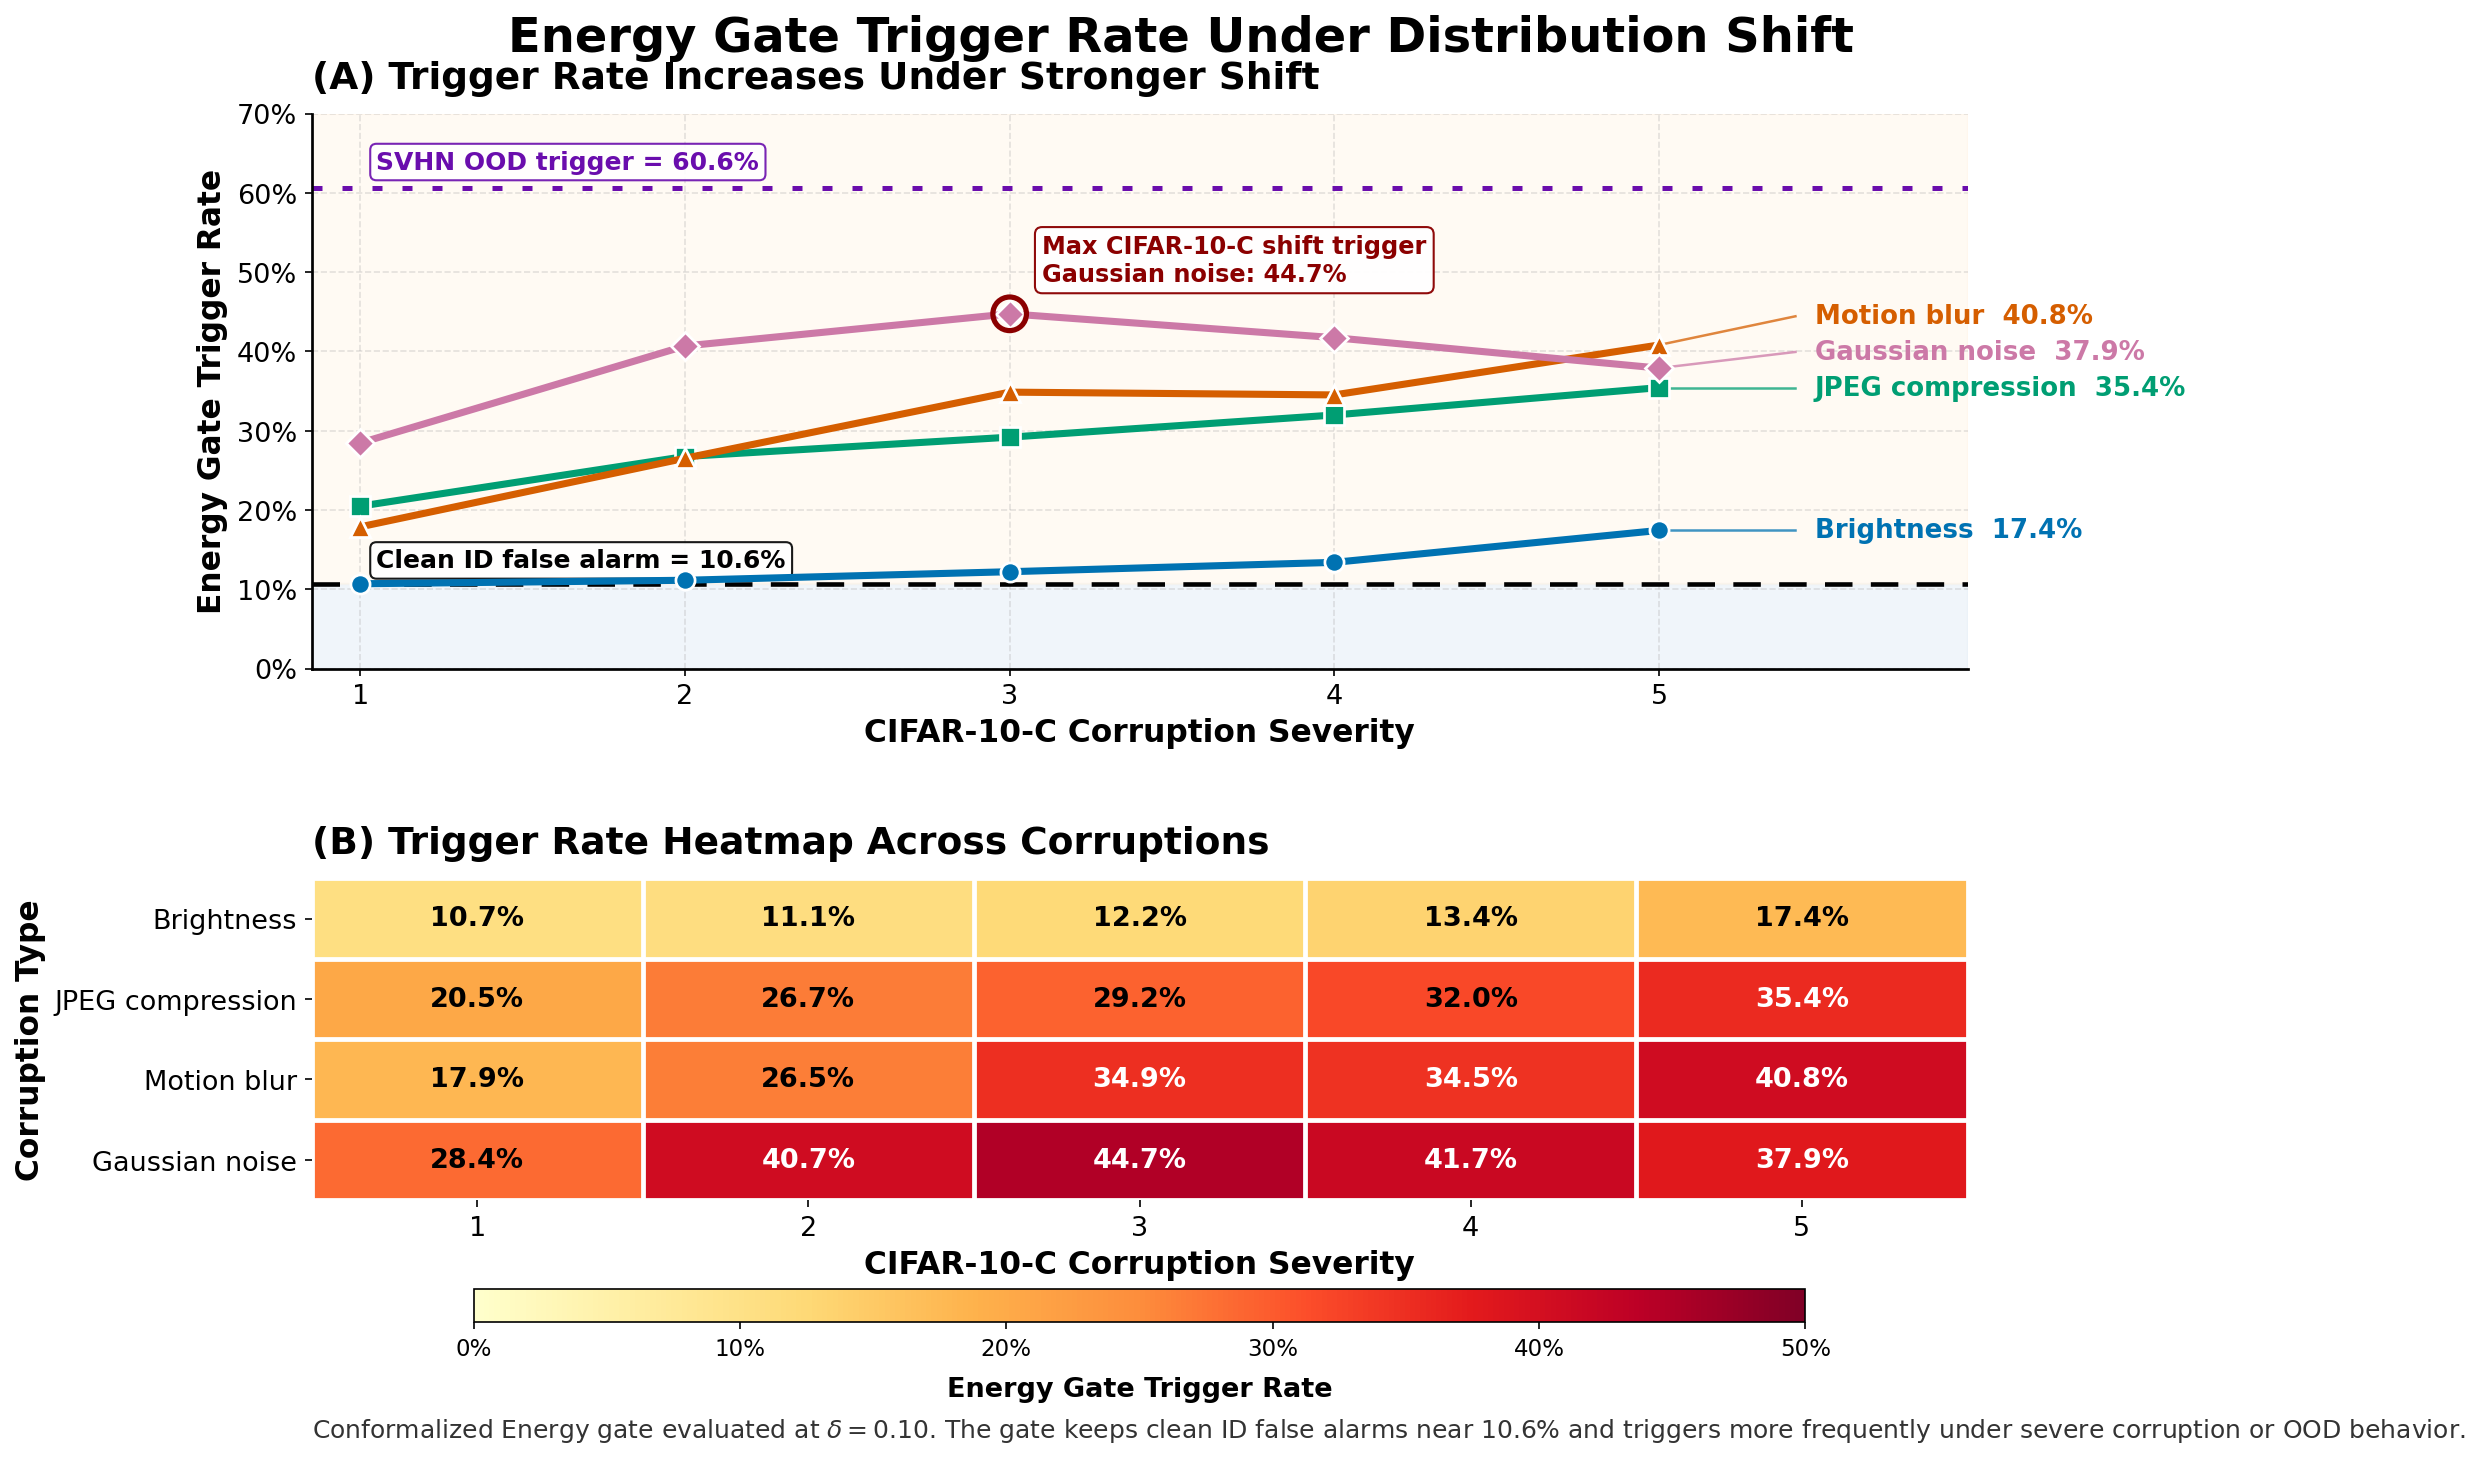

Saved PNG: shift_aware_conformal_outputs/final_poster_figures/advanced_vertical_energy_gate_trigger_rate_under_shift_delta_0p10.png
Saved PDF: shift_aware_conformal_outputs/final_poster_figures/advanced_vertical_energy_gate_trigger_rate_under_shift_delta_0p10.pdf
Saved SVG: shift_aware_conformal_outputs/final_poster_figures/advanced_vertical_energy_gate_trigger_rate_under_shift_delta_0p10.svg


In [3]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter


# Figure 2: Energy Gate Trigger Rate Under Shift


OUTPUT_ROOT = Path("shift_aware_conformal_outputs")
SHIFT_CSV = OUTPUT_ROOT / "step3b_energy_gate_cifar10c.csv"
SUMMARY_CSV = OUTPUT_ROOT / "step3b_energy_gate_summary.csv"

FIG_DIR = OUTPUT_ROOT / "final_poster_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

DELTA_VALUE = 0.10


shift_df = pd.read_csv(SHIFT_CSV)
summary_df = pd.read_csv(SUMMARY_CSV)

def clean_columns(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
        .str.replace("-", "_")
    )
    return df

shift_df = clean_columns(shift_df)
summary_df = clean_columns(summary_df)

required_shift_cols = ["corruption", "severity", "delta", "trigger_rate"]
required_summary_cols = ["dataset", "delta", "trigger_rate"]

missing_shift = [c for c in required_shift_cols if c not in shift_df.columns]
missing_summary = [c for c in required_summary_cols if c not in summary_df.columns]

if missing_shift:
    raise ValueError(f"Missing shift columns: {missing_shift}. Available: {shift_df.columns.tolist()}")

if missing_summary:
    raise ValueError(f"Missing summary columns: {missing_summary}. Available: {summary_df.columns.tolist()}")

plot_df = shift_df[np.isclose(shift_df["delta"], DELTA_VALUE)].copy()
summary_delta = summary_df[np.isclose(summary_df["delta"], DELTA_VALUE)].copy()

if plot_df.empty:
    raise ValueError(f"No rows found for delta={DELTA_VALUE}")

if summary_delta.empty:
    raise ValueError(f"No summary rows found for delta={DELTA_VALUE}")


summary_delta["dataset_lower"] = summary_delta["dataset"].astype(str).str.lower()

clean_rows = summary_delta[
    summary_delta["dataset_lower"].str.contains("clean")
]

svhn_rows = summary_delta[
    summary_delta["dataset_lower"].str.contains("svhn")
]

if clean_rows.empty:
    raise ValueError(f"Could not find clean ID row. Datasets: {summary_delta['dataset'].tolist()}")

if svhn_rows.empty:
    raise ValueError(f"Could not find SVHN row. Datasets: {summary_delta['dataset'].tolist()}")

clean_fa = float(clean_rows["trigger_rate"].iloc[0])
svhn_trigger = float(svhn_rows["trigger_rate"].iloc[0])


name_map = {
    "brightness": "Brightness",
    "jpeg_compression": "JPEG compression",
    "motion_blur": "Motion blur",
    "gaussian_noise": "Gaussian noise",
}

plot_order = [
    "brightness",
    "jpeg_compression",
    "motion_blur",
    "gaussian_noise",
]

colors = {
    "brightness": "#0072B2",
    "jpeg_compression": "#009E73",
    "motion_blur": "#D55E00",
    "gaussian_noise": "#CC79A7",
}

markers = {
    "brightness": "o",
    "jpeg_compression": "s",
    "motion_blur": "^",
    "gaussian_noise": "D",
}

plot_df = plot_df[plot_df["corruption"].isin(plot_order)].copy()

plot_df["corruption"] = pd.Categorical(
    plot_df["corruption"],
    categories=plot_order,
    ordered=True
)

plot_df = plot_df.sort_values(["corruption", "severity"])

heat_df = plot_df.pivot(
    index="corruption",
    columns="severity",
    values="trigger_rate"
).loc[plot_order]

heat_values = heat_df.values


plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 13,
    "axes.titlesize": 18,
    "axes.labelsize": 15,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


fig = plt.figure(figsize=(13.8, 10.2))

gs = fig.add_gridspec(
    nrows=2,
    ncols=1,
    height_ratios=[1.25, 1.0],
    left=0.08,
    right=0.88,
    bottom=0.11,
    top=0.90,
    hspace=0.42
)

ax_line = fig.add_subplot(gs[0, 0])
ax_hm = fig.add_subplot(gs[1, 0])



# Background zones
ax_line.axhspan(0.0, clean_fa, color="#EAF2F8", alpha=0.70, zorder=0)
ax_line.axhspan(clean_fa, 0.70, color="#FFF4E6", alpha=0.45, zorder=0)

# Reference lines
ax_line.axhline(
    clean_fa,
    color="black",
    linestyle=(0, (6, 4)),
    linewidth=2.2,
    zorder=2
)

ax_line.axhline(
    svhn_trigger,
    color="#6A0DAD",
    linestyle=(0, (2, 4)),
    linewidth=2.4,
    zorder=2
)

# Reference labels
ax_line.text(
    1.05,
    clean_fa + 0.015,
    f"Clean ID false alarm = {100 * clean_fa:.1f}%",
    fontsize=12,
    color="black",
    fontweight="bold",
    ha="left",
    va="bottom",
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="black", alpha=0.90)
)

ax_line.text(
    1.05,
    svhn_trigger + 0.018,
    f"SVHN OOD trigger = {100 * svhn_trigger:.1f}%",
    fontsize=12,
    color="#6A0DAD",
    fontweight="bold",
    ha="left",
    va="bottom",
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="#6A0DAD", alpha=0.90)
)

# Plot curves
end_points = []

for corruption in plot_order:
    sub = plot_df[plot_df["corruption"] == corruption].sort_values("severity")

    ax_line.plot(
        sub["severity"],
        sub["trigger_rate"],
        color=colors[corruption],
        marker=markers[corruption],
        linewidth=3.4,
        markersize=9.2,
        markeredgecolor="white",
        markeredgewidth=1.3,
        zorder=3
    )

    last_x = float(sub["severity"].iloc[-1])
    last_y = float(sub["trigger_rate"].iloc[-1])
    end_points.append((corruption, last_x, last_y))


end_points = sorted(end_points, key=lambda x: x[2])

min_gap = 0.045
label_positions = {}

last_y = -999
for corruption, x, y in end_points:
    y_label = max(y, last_y + min_gap)
    label_positions[corruption] = y_label
    last_y = y_label

# If labels exceed axis top, shift them down together
max_allowed = 0.665
overflow = max(label_positions.values()) - max_allowed

if overflow > 0:
    for corruption in label_positions:
        label_positions[corruption] -= overflow

for corruption, x, y in end_points:
    y_label = label_positions[corruption]

    ax_line.plot(
        [x, 5.42],
        [y, y_label],
        color=colors[corruption],
        linewidth=1.2,
        alpha=0.75,
        zorder=2
    )

    ax_line.text(
        5.48,
        y_label,
        f"{name_map[corruption]}  {100 * y:.1f}%",
        color=colors[corruption],
        fontsize=12.5,
        fontweight="bold",
        va="center",
        ha="left"
    )

# Highlight maximum trigger
max_row = plot_df.loc[plot_df["trigger_rate"].idxmax()]
max_x = float(max_row["severity"])
max_y = float(max_row["trigger_rate"])
max_corr = str(max_row["corruption"])

ax_line.scatter(
    [max_x],
    [max_y],
    s=260,
    facecolors="none",
    edgecolors="#8B0000",
    linewidths=2.5,
    zorder=5
)

ax_line.text(
    max_x + 0.10,
    max_y + 0.035,
    f"Max CIFAR-10-C shift trigger\n{name_map[max_corr]}: {100 * max_y:.1f}%",
    fontsize=11.5,
    color="#8B0000",
    fontweight="bold",
    ha="left",
    va="bottom",
    bbox=dict(
        boxstyle="round,pad=0.30",
        facecolor="white",
        edgecolor="#8B0000",
        alpha=0.96
    )
)

ax_line.set_title("(A) Trigger Rate Increases Under Stronger Shift", loc="left", pad=12)
ax_line.set_xlabel("CIFAR-10-C Corruption Severity")
ax_line.set_ylabel("Energy Gate Trigger Rate")

ax_line.set_xlim(0.85, 5.95)
ax_line.set_ylim(0.0, 0.70)
ax_line.set_xticks([1, 2, 3, 4, 5])
ax_line.yaxis.set_major_formatter(PercentFormatter(1.0))

ax_line.grid(True, linestyle="--", linewidth=0.8, alpha=0.35)

ax_line.spines["top"].set_visible(False)
ax_line.spines["right"].set_visible(False)
ax_line.spines["left"].set_linewidth(1.3)
ax_line.spines["bottom"].set_linewidth(1.3)



im = ax_hm.imshow(
    heat_values,
    aspect="auto",
    cmap="YlOrRd",
    vmin=0.0,
    vmax=max(0.50, np.nanmax(heat_values))
)

ax_hm.set_title("(B) Trigger Rate Heatmap Across Corruptions", loc="left", pad=12)
ax_hm.set_xlabel("CIFAR-10-C Corruption Severity")
ax_hm.set_ylabel("Corruption Type")

ax_hm.set_xticks(np.arange(len(heat_df.columns)))
ax_hm.set_xticklabels([str(c) for c in heat_df.columns])

ax_hm.set_yticks(np.arange(len(heat_df.index)))
ax_hm.set_yticklabels([name_map[c] for c in heat_df.index])

# Annotate heatmap cells
for i in range(heat_values.shape[0]):
    for j in range(heat_values.shape[1]):
        val = heat_values[i, j]
        text_color = "white" if val >= 0.34 else "black"

        ax_hm.text(
            j,
            i,
            f"{100 * val:.1f}%",
            ha="center",
            va="center",
            fontsize=13,
            fontweight="bold",
            color=text_color
        )

# Heatmap grid
for spine in ax_hm.spines.values():
    spine.set_visible(False)

ax_hm.set_xticks(np.arange(-0.5, len(heat_df.columns), 1), minor=True)
ax_hm.set_yticks(np.arange(-0.5, len(heat_df.index), 1), minor=True)
ax_hm.grid(which="minor", color="white", linestyle="-", linewidth=2.3)
ax_hm.tick_params(which="minor", bottom=False, left=False)

# Horizontal colorbar under heatmap
cbar = fig.colorbar(
    im,
    ax=ax_hm,
    orientation="horizontal",
    fraction=0.075,
    pad=0.20,
    aspect=40
)

cbar.set_label("Energy Gate Trigger Rate", fontsize=13, fontweight="bold", labelpad=8)
cbar.ax.xaxis.set_major_formatter(PercentFormatter(1.0))
cbar.ax.tick_params(labelsize=11)


fig.suptitle(
    "Energy Gate Trigger Rate Under Distribution Shift",
    fontsize=23,
    fontweight="bold",
    y=0.965
)

fig.text(
    0.08,
    0.035,
    rf"Conformalized Energy gate evaluated at $\delta={DELTA_VALUE:.2f}$. "
    rf"The gate keeps clean ID false alarms near {100 * clean_fa:.1f}% and triggers more frequently under severe corruption or OOD behavior.",
    fontsize=12,
    color="#333333"
)


base_name = "advanced_vertical_energy_gate_trigger_rate_under_shift_delta_0p10"

png_path = FIG_DIR / f"{base_name}.png"
pdf_path = FIG_DIR / f"{base_name}.pdf"
svg_path = FIG_DIR / f"{base_name}.svg"

plt.savefig(png_path, bbox_inches="tight", dpi=600)
plt.savefig(pdf_path, bbox_inches="tight")
plt.savefig(svg_path, bbox_inches="tight")

plt.show()

print("Saved PNG:", png_path)
print("Saved PDF:", pdf_path)
print("Saved SVG:", svg_path)